# 01. 그린빈 수입 데이터 검증 & 수입 추세 분석 (HS 090111)

**목적**: 관세청 OpenAPI로 수집한 한국 생두(green bean) 수입 raw 데이터를
검증하고, 월간 리포트 *Section 2 — Green Bean Import Trend* 에 쓸 집계와 인사이트를 도출한다.

- 입력: `data/raw/korea_green_bean_imports_hs090111_2024_2026.csv`
- 출력: `data/processed/monthly_import_summary.csv`, `data/processed/origin_summary.csv`


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

RAW = "../data/raw/korea_green_bean_imports_hs090111_2024_2026.csv"
df = pd.read_csv(RAW, dtype={"hs_code": str, "country_code": str})
df["date"] = pd.to_datetime(df["year_month"], format="%Y-%m")
df.head()

Matplotlib is building the font cache; this may take a moment.


,year_month,hs_code,item_name,country,country_code,import_weight_kg,import_value_usd,source,notes,date
0,2024-01,090111,카페인을 제거하지 않은 것,아랍에미리트 연합,AE,1,16,Korea Customs Service OpenAPI (data.go.kr),NaN,2024-01-01
1,2024-01,090111,카페인을 제거하지 않은 것,부룬디,BI,1,24,Korea Customs Service OpenAPI (data.go.kr),NaN,2024-01-01
2,2024-01,090111,카페인을 제거하지 않은 것,볼리비아,BO,17,238,Korea Customs Service OpenAPI (data.go.kr),NaN,2024-01-01
3,2024-01,090111,카페인을 제거하지 않은 것,브라질,BR,6605432,24076036,Korea Customs Service OpenAPI (data.go.kr),NaN,2024-01-01
4,2024-01,090111,카페인을 제거하지 않은 것,스위스,CH,10,140,Korea Customs Service OpenAPI (data.go.kr),NaN,2024-01-01


## 1. 데이터 검증 (Data Validation)

리포트의 신뢰도는 raw 데이터 품질에서 나온다. 분석 전에 기본 무결성을 확인한다.

In [2]:
checks = {
    "총 행 수": len(df),
    "기간": f"{df.year_month.min()} ~ {df.year_month.max()}",
    "개월 수": df.year_month.nunique(),
    "중복 (월+국가)": int(df.duplicated(["year_month", "country_code"]).sum()),
    "음수 중량": int((df.import_weight_kg < 0).sum()),
    "음수 금액": int((df.import_value_usd < 0).sum()),
    "결측 (핵심컬럼)": int(df[["year_month","country_code","import_weight_kg","import_value_usd"]].isnull().sum().sum()),
}
for k, v in checks.items():
    print(f"{k:18s}: {v}")
print()
print("월별 국가 수 (min/median/max):",
      df.groupby("year_month").size().min(),
      int(df.groupby("year_month").size().median()),
      df.groupby("year_month").size().max())

총 행 수             : 1082
기간                : 2024-01 ~ 2026-04
개월 수              : 28
중복 (월+국가)         : 0
음수 중량             : 0
음수 금액             : 0
결측 (핵심컬럼)         : 0

월별 국가 수 (min/median/max): 33 38 47


**판정**: 중복·음수·결측 없음, 28개월 연속, 월 33~47개국 → 분석에 사용 가능.

## 2. 월별 수입 추세 (Monthly Import Trend)

월별 총 수입중량(톤), 총 수입금액(USD), 그리고 둘에서 도출한 **평균 단가(USD/kg)** 를 본다.
단가 = 금액 / 중량 → 가격 효과와 물량 효과를 분리해서 볼 수 있다.

In [3]:
m = (df.groupby("year_month")
       .agg(total_weight_kg=("import_weight_kg", "sum"),
            total_value_usd=("import_value_usd", "sum"),
            n_countries=("country_code", "nunique"))
       .reset_index())
m["total_weight_ton"] = (m.total_weight_kg / 1000).round(1)
m["avg_unit_price_usd_per_kg"] = (m.total_value_usd / m.total_weight_kg).round(3)
m = m[["year_month", "total_weight_kg", "total_weight_ton",
       "total_value_usd", "avg_unit_price_usd_per_kg", "n_countries"]]

m.to_csv("../data/processed/monthly_import_summary.csv", index=False, encoding="utf-8-sig")
m

,year_month,total_weight_kg,total_weight_ton,total_value_usd,avg_unit_price_usd_per_kg,n_countries
0,2024-01,16411523,16411.5,63689214,3.881,35
1,2024-02,11872546,11872.5,46798141,3.942,34
2,2024-03,12354574,12354.6,51237638,4.147,40
3,2024-04,15531561,15531.6,65943600,4.246,38
4,2024-05,13641384,13641.4,61679698,4.522,40
5,2024-06,14291286,14291.3,68396446,4.786,33
6,2024-07,16792784,16792.8,87101479,5.187,40
7,2024-08,16903471,16903.5,87245852,5.161,39
8,2024-09,12209747,12209.7,64070797,5.248,36
9,2024-10,16400054,16400.1,90136372,5.496,39


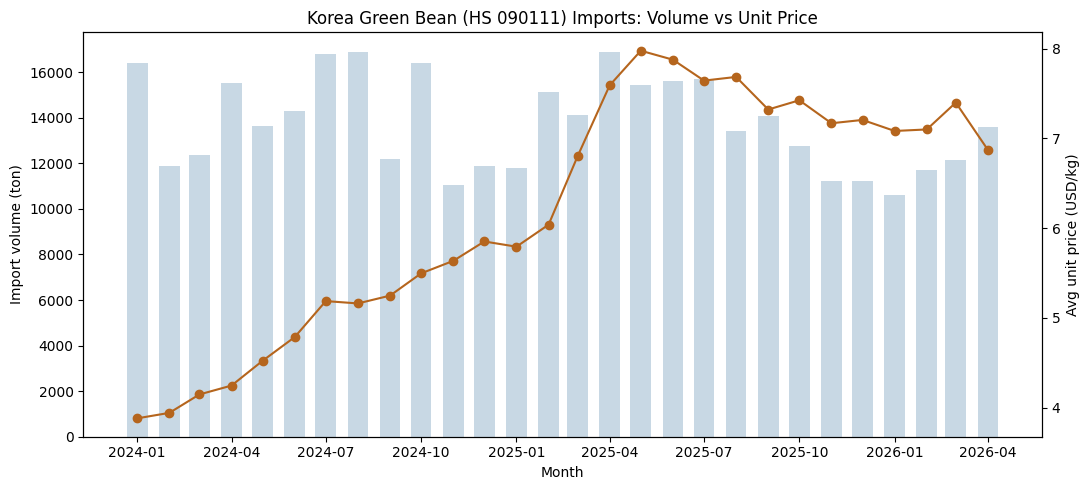

In [4]:
# 물량(막대) vs 평균단가(선) — 가격 효과를 한눈에
x = pd.to_datetime(m.year_month, format="%Y-%m")
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(x, m.total_weight_ton, width=20, color="#c8d8e4", label="Import volume (ton)")
ax1.set_ylabel("Import volume (ton)")
ax1.set_xlabel("Month")

ax2 = ax1.twinx()
ax2.plot(x, m.avg_unit_price_usd_per_kg, color="#b5651d", marker="o", label="Unit price (USD/kg)")
ax2.set_ylabel("Avg unit price (USD/kg)")

plt.title("Korea Green Bean (HS 090111) Imports: Volume vs Unit Price")
fig.tight_layout()
plt.show()

**관찰**: 물량은 월 ~12~16천 톤 박스권으로 비교적 평탄한 반면, **평균 단가는 약 \$3.9/kg → ~\$7/kg 로 거의 2배 상승**.
즉 수입 *금액* 증가는 물량이 아니라 **가격(국제 시세)** 이 견인했다.
→ 이는 Section 3(International Coffee Price)와 직접 연결되는 핵심 스토리라인.

## 3. 원산지 구조 (Origin Mix)

어느 나라에서 들어오는지, 집중도가 얼마나 높은지 본다. 공급 리스크(Section 5)의 기초.

In [5]:
top = (df.groupby(["country_code", "country"])
         .agg(total_weight_kg=("import_weight_kg", "sum"),
              total_value_usd=("import_value_usd", "sum"))
         .reset_index()
         .sort_values("total_weight_kg", ascending=False))
top["share_pct"] = (top.total_weight_kg / top.total_weight_kg.sum() * 100).round(1)
top.to_csv("../data/processed/origin_summary.csv", index=False, encoding="utf-8-sig")
top.head(10)

,country_code,country,total_weight_kg,total_value_usd,share_pct
8,BR,브라질,130387933,803413497,33.9
81,VN,베트남,64091576,291823498,16.7
18,CO,콜롬비아,63364889,436183575,16.5
27,ET,에티오피아,47118604,321816753,12.2
34,GT,과테말라,16901205,121691984,4.4
38,IN,인도,13420221,69871572,3.5
36,HN,온두라스,12549905,72916974,3.3
62,PE,페루,9059064,51391335,2.4
43,KE,케냐,6292500,45469197,1.6
37,ID,인도네시아,5233279,34286581,1.4


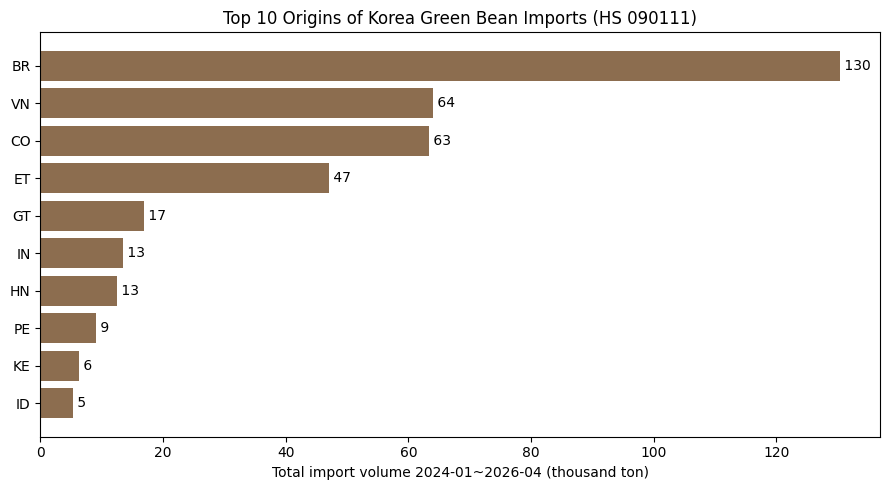

In [6]:
t10 = top.head(10)[::-1]   # reversed for horizontal bar
plt.figure(figsize=(9, 5))
plt.barh(t10.country_code, t10.total_weight_kg / 1e6, color="#8c6d4f")
plt.xlabel("Total import volume 2024-01~2026-04 (thousand ton)")
plt.title("Top 10 Origins of Korea Green Bean Imports (HS 090111)")
for i, (code_, v) in enumerate(zip(t10.country_code, t10.total_weight_kg / 1e6)):
    plt.text(v, i, f" {v:,.0f}", va="center")
plt.tight_layout()
plt.show()

**관찰**: 상위 4개국(브라질·베트남·콜롬비아·에티오피아)이 전체 물량의 약 **79%** 차지 → 원산지 집중도 높음.
특정 산지의 작황·물류 이슈가 한국 수입에 즉각 영향 → Section 5에서 추적할 대상.

## 다음 단계
- Section 3: ICO 국제 커피 가격 데이터 수집 → 위 단가 상승과 교차 검증
- Section 5: 상위 원산지(브라질·베트남 등) 공급 리스크 뉴스 수집